# NFL Draft Analysis: WR Draft Capital vs. NFL Production
## Executive Summary

**Key Question:** How do draft rounds correlate with NFL success for wide receivers?

**Approach:** Created a tiered classification system (Elite/Hit/Role/Bust) based on single-season yardage and touchdown thresholds, then analyzed 291 WRs drafted from 2017-2025.

**Key Findings:**

- **Round 1 is the only reliable source of elite talent** (16.2% elite rate), with 86.5% of first-rounders becoming at least solid starters (Elite + Hit + Role)

- **Round 2 offers the best value among Day 2 picks** - 31.0% bust rate vs. 58.8% in Round 3, with 4.8% still becoming elite

- **The bust rate spikes after Round 2** - from 31.0% in Round 2 to 58.8% in Round 3, then consistently above 70% in Rounds 4-7

- **Day 3 WRs (Rounds 4-7) are lottery tickets** - 70-90% bust rate, with elite talent appearing in only 3-4% of picks (and never after Round 5)

- **53 players (18.2%) from 2024-2025 are flagged "Too Early"** - this analysis will need updating as their careers develop

**Bottom Line:** If you want an elite WR, you need to draft one in Round 1. If you want a solid starter, Round 2 is your best value. After Round 3, you're playing the odds - and the odds are terrible.

### Goal
Analyze the relationship between draft position and subsequent NFL performance for wide receivers.

**Database Creation**

Before I do anything else, I need to load all the csv files I have and add them as a table in my SQLite database

In [2]:
import sqlite3
import pandas as pd
import os

# connect to database (will create if doesn't exist)
conn = sqlite3.connect('nfl_analytics.db')
print("Connected to database")

# dictionary mapping table names to their CSV file paths
files = {
    'draft_picks': '../data/NFLDraftPositionWR2011-2025.csv',
    'nextgen': '../data/NextGenWRStats2018-2025.csv',
    'combine': '../data/NFLCombineStats2017-2025.csv',
    'college': '../data/CollegeReceivingStats2017-2025.csv'
}

# load each file into its own SQLite table
for table_name, file_path in files.items():
    try:
        df = pd.read_csv(file_path)
        df.to_sql(table_name, conn, if_exists='replace', index=False)
        print(f"Loaded {table_name}: {len(df)} rows")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

conn.close()
print("\nConnection closed")

Connected to database
Loaded draft_picks: 481 rows
Loaded nextgen: 995 rows
Loaded combine: 550 rows
Loaded college: 2700 rows

Connection closed


## Determining Tier Thresholds

Before finalizing my tier definitions, I need to understand the distribution of receiving yards across all WR seasons in the NextGen data.

**Why the 45-target filter?** NextGen Stats only includes players with 45+ targets in a season. This is actually helpful because it automatically filters out:
- Players who were injured and missed significant time
- Players who weren't good enough to earn playing time
- Depth players who never became contributors

**Important note on rookies:** A rookie drafted in 2024 who gets 40 targets isn't necessarily a bust - they might just need time to develop. I'll handle this with a "Too Early" flag for recent draft classes.

The distribution below will show me natural breakpoints in the data to validate my tier thresholds.

In [3]:
import sqlite3
import pandas as pd

# connect to database
conn = sqlite3.connect('nfl_analytics.db')

# distribution analysis to validate tier thresholds
# this query groups WR seasons into yardage buckets
# and shows how many seasons/players fall into each
query = """
SELECT 
    CASE 
        WHEN YDS >= 1200 THEN '1200+'
        WHEN YDS >= 800 THEN '800-1199'
        WHEN YDS >= 400 THEN '400-799'
        ELSE 'Under 400'
    END as yards_tier,
    COUNT(*) as seasons,
    COUNT(DISTINCT NAME) as players,
    ROUND(AVG(TD), 1) as avg_tds
FROM nextgen
WHERE POS = 'WR'
GROUP BY yards_tier
ORDER BY MIN(YDS);
"""

yards_dist = pd.read_sql_query(query, conn)
print("WR SEASONS BY YARDS TIER")
print("=" * 60)
print(yards_dist.to_string(index=False))

conn.close()

WR SEASONS BY YARDS TIER
yards_tier  seasons  players  avg_tds
 Under 400      111       95      1.9
   400-799      365      199      3.6
  800-1199      205       93      6.0
     1200+       64       40      9.3


## Methodology: Defining WR Tiers

Based on the distribution analysis above, I established the following tier thresholds:

| Tier | Yards Threshold | Touchdown Threshold | Supporting Data |
|------|-----------------|---------------------|-----------------|
| **Elite** | 1,200+ yards | OR 10+ TDs | Only 64 seasons (40 players) reached this level - true difference-makers |
| **Hit** | 800-1,199 yards | OR 6-9 TDs | 205 seasons (93 players) - clear starter production |
| **Role** | 400-799 yards | OR 3-5 TDs | 365 seasons (199 players) - solid contributors |
| **Bust** | Never hit 400 yards | AND never hit 3 TDs | 111 seasons (95 players) - never became consistent contributors |

**Important Notes:**
- **Why these numbers?** The 400/800/1200 thresholds represent natural breakpoints in the data where the number of seasons and average touchdowns meaningfully change.
- **45-target filter:** NextGen Stats only includes players with 45+ targets, so "Bust" here means they either never reached that threshold or performed below it when they did.
- **Recent draftees (2024-2025):** Players from these classes who haven't yet reached Hit/Elite status are flagged as "Too Early" - they need more time to develop.

**First Step: Joining Draft and Production Data**
Now that I have my tier definitions, I need to connect each drafted player to their NFL seasons.

In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# validate that our join is working correctly
# this sample will show us if player names are matching properly
query_check = """
SELECT 
    d.Name as draft_name,
    d.Year as draft_year,
    d.Round,
    n.NAME as nextgen_name,
    n.YEAR as nextgen_year,
    n.YDS,
    n.TD
FROM draft_picks d
LEFT JOIN nextgen n ON d.Name = n.NAME
WHERE d.Year BETWEEN 2017 AND 2025
    AND d.Name NOT LIKE '%pick%'
    AND d.Name NOT LIKE '%Pick%'
LIMIT 30;
"""

sample = pd.read_sql_query(query_check, conn)
print("SAMPLE OF JOIN RESULTS:")
print(sample.to_string())

# now check the match rate
query_count = """
SELECT 
    COUNT(DISTINCT d.Name) as total_drafted,
    COUNT(DISTINCT n.NAME) as have_nextgen_data
FROM draft_picks d
LEFT JOIN nextgen n ON d.Name = n.NAME
WHERE d.Year BETWEEN 2017 AND 2025
    AND d.Name NOT LIKE '%pick%';
"""

counts = pd.read_sql_query(query_count, conn)
print("\nMATCH STATS:")
print(counts)

conn.close()

🔍 SAMPLE OF JOIN RESULTS:
               draft_name  draft_year  Round       nextgen_name  nextgen_year     YDS   TD
0           Travis Hunter        2025      1      Travis Hunter        2025.0   298.0  1.0
1       Tetairoa McMillan        2025      1  Tetairoa McMillan        2025.0  1013.0  7.0
2            Emeka Egbuka        2025      1       Emeka Egbuka        2025.0   938.0  6.0
3          Matthew Golden        2025      1                NaN           NaN     NaN  NaN
4          Jayden Higgins        2025      2     Jayden Higgins        2025.0   525.0  6.0
5           Luther Burden        2025      2      Luther Burden        2025.0   652.0  2.0
6              Tre Harris        2025      2                NaN           NaN     NaN  NaN
7               Jack Bech        2025      2                NaN           NaN     NaN  NaN
8           Kyle Williams        2025      3                NaN           NaN     NaN  NaN
9            Isaac TeSlaa        2025      3                NaN 

## Full Analysis: Hit Rates by Draft Round

Now that I've validated the join is working correctly, I'll run the complete analysis. This query will:

1. **Classify each player's best season** using the tier thresholds established above
2. **Determine final career tier** based on their best seasons
3. **Flag recent draftees** (2024-2025) as "Too Early" if they haven't yet broken through
4. **Calculate hit rates by round** to identify where teams find the best value

In [5]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- first, classify each player's BEST season
    SELECT 
        n.NAME,
        MAX(CASE 
            WHEN n.YDS >= 1200 OR n.TD >= 10 THEN 'Elite'
            WHEN n.YDS >= 800 OR n.TD >= 6 THEN 'Hit'
            WHEN n.YDS >= 400 OR n.TD >= 3 THEN 'Role'
            ELSE 'Below Role'
        END) as peak_tier,
        MAX(n.YDS) as peak_yards,
        MAX(n.TD) as peak_tds,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
drafted_players AS (
    -- Get all drafted WRs 2017-2025
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Pick,
        pt.peak_tier,
        pt.peak_yards,
        pt.peak_tds,
        pt.seasons_in_nextgen,
        -- Determine final tier with "Too Early" logic
        CASE 
            -- Too Early (2024-2025 draftees with no Elite/Hit yet)
            WHEN d.Year >= 2024 AND (pt.peak_tier IS NULL OR pt.peak_tier IN ('Below Role', 'Role')) THEN 'Too Early'
            -- Never appeared in NextGen = Bust
            WHEN pt.peak_tier IS NULL THEN 'Bust'
            -- Appeared but never hit Role = Bust
            WHEN pt.peak_tier = 'Below Role' THEN 'Bust'
            -- Everything else
            ELSE pt.peak_tier
        END as final_tier
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
        AND d.Name NOT LIKE '%pick%'
        AND d.Name NOT LIKE '%Pick%'
        AND d.Name NOT LIKE '%selection%'
        AND d.Name NOT LIKE '%Forfeit%'
)
-- Final summary by round
SELECT 
    Round,
    COUNT(*) as total_drafted,
    SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) as elite_count,
    SUM(CASE WHEN final_tier = 'Hit' THEN 1 ELSE 0 END) as hit_count,
    SUM(CASE WHEN final_tier = 'Role' THEN 1 ELSE 0 END) as role_count,
    SUM(CASE WHEN final_tier = 'Bust' THEN 1 ELSE 0 END) as bust_count,
    SUM(CASE WHEN final_tier = 'Too Early' THEN 1 ELSE 0 END) as too_early_count,
    -- Calculate percentages (excluding Too Early)
    ROUND(SUM(CASE WHEN final_tier IN ('Elite', 'Hit', 'Role') THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as success_rate,
    ROUND(SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as elite_rate
FROM drafted_players
GROUP BY Round
ORDER BY Round;
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("WR HIT RATE BY DRAFT ROUND (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

total_players = results['total_drafted'].sum()
total_evaluated = total_players - results['too_early_count'].sum()
print(f"Total WRs drafted 2017-2025: {total_players}")
print(f"Evaluated (excluding Too Early): {total_evaluated}")
print(f"Too Early (2024-2025): {results['too_early_count'].sum()}")

conn.close()

WR HIT RATE BY DRAFT ROUND (2017-2025)
 Round  total_drafted  elite_count  hit_count  role_count  bust_count  too_early_count  success_rate  elite_rate
     1             39            1         11          17           2                8          93.5         3.2
     2             46            0          7          24           9                6          77.5         0.0
     3             44            0          2          16          16               10          52.9         0.0
     4             38            0          3           6          19               10          32.1         0.0
     5             35            0          1           9          19                6          34.5         0.0
     6             47            0          1          14          22               10          40.5         0.0
     7             42            0          0           5          27               10          15.6         0.0

OVERALL SUMMARY
Total WRs drafted 2017-2025: 291
Evaluat

## Fixing the Classification Logic

My first attempt had a flaw: using `MAX()` on string values sorts alphabetically, not by tier quality. This misclassified players (e.g., 'Hit' > 'Elite' alphabetically).

**The fix:** Assign numeric scores to tiers:
- 4 = Elite
- 3 = Hit
- 2 = Role
- 1 = Below Role

Now `MAX()` will correctly identify each player's best season. The query below implements this fix.

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- use numeric scores for proper MAX comparison
    SELECT 
        n.NAME,
        MAX(CASE 
            WHEN n.YDS >= 1200 OR n.TD >= 10 THEN 4  -- Elite
            WHEN n.YDS >= 800 OR n.TD >= 6 THEN 3    -- Hit
            WHEN n.YDS >= 400 OR n.TD >= 3 THEN 2    -- Role
            ELSE 1                                   -- Below Role
        END) as tier_score,
        MAX(n.YDS) as peak_yards,
        MAX(n.TD) as peak_tds,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
drafted_players AS (
    -- get all drafted WRs 2017-2025
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Pick,
        CASE 
            WHEN pt.tier_score = 4 THEN 'Elite'
            WHEN pt.tier_score = 3 THEN 'Hit'
            WHEN pt.tier_score = 2 THEN 'Role'
            WHEN pt.tier_score = 1 THEN 'Below Role'
            ELSE NULL
        END as peak_tier,
        pt.peak_yards,
        pt.peak_tds,
        pt.seasons_in_nextgen,
        -- determine final tier with "Too Early" logic
        CASE 
            -- Too Early (2024-2025 draftees not yet proven)
            WHEN d.Year >= 2024 AND (pt.tier_score IS NULL OR pt.tier_score <= 2) THEN 'Too Early'
            -- Never appeared in NextGen = Bust
            WHEN pt.tier_score IS NULL THEN 'Bust'
            -- Appeared but never hit Role = Bust
            WHEN pt.tier_score = 1 THEN 'Bust'
            -- Everything else - map numeric back to tier
            WHEN pt.tier_score = 4 THEN 'Elite'
            WHEN pt.tier_score = 3 THEN 'Hit'
            WHEN pt.tier_score = 2 THEN 'Role'
        END as final_tier
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
)
-- final summary by round
SELECT 
    Round,
    COUNT(*) as total_drafted,
    SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) as elite_count,
    SUM(CASE WHEN final_tier = 'Hit' THEN 1 ELSE 0 END) as hit_count,
    SUM(CASE WHEN final_tier = 'Role' THEN 1 ELSE 0 END) as role_count,
    SUM(CASE WHEN final_tier = 'Bust' THEN 1 ELSE 0 END) as bust_count,
    SUM(CASE WHEN final_tier = 'Too Early' THEN 1 ELSE 0 END) as too_early_count,
    -- Calculate percentages (excluding Too Early)
    ROUND(SUM(CASE WHEN final_tier IN ('Elite', 'Hit', 'Role') THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as success_rate,
    ROUND(SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as elite_rate
FROM drafted_players
GROUP BY Round
ORDER BY Round;
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("WR HIT RATE BY DRAFT ROUND (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

total_players = results['total_drafted'].sum()
total_evaluated = total_players - results['too_early_count'].sum()
print(f"Total WRs drafted 2017-2025: {total_players}")
print(f"Evaluated (excluding Too Early): {total_evaluated}")
print(f"Too Early (2024-2025): {results['too_early_count'].sum()}")

conn.close()

WR HIT RATE BY DRAFT ROUND (2017-2025)
 Round  total_drafted  elite_count  hit_count  role_count  bust_count  too_early_count  success_rate  elite_rate
     1             39           16         14           3           2                4          94.3        45.7
     2             47            6         16          10           9                6          78.0        14.6
     3             44            5          6           7          16               10          52.9        14.7
     4             38            1          3           5          19               10          32.1         3.6
     5             35            1          6           3          19                6          34.5         3.4
     6             47            0          5          10          22               10          40.5         0.0
     7             42            0          2           3          27               10          15.6         0.0

OVERALL SUMMARY
Total WRs drafted 2017-2025: 292
Evaluat

## Validation: Manual Check of 5th Round "Elite" WRs

My analysis showed only one elite receiver drafted in the 5th round since 2017: Puka Nacua. Before accepting this finding, I wanted to verify it manually by examining all 5th round WR selections.

**Why this matters:** If I missed someone, my conclusion about 5th round value would be wrong. This check ensures accuracy.

In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# pull all 5th round WRs so I can manually check for any potential Elite players I might have missed
query = """
SELECT 
    Year,
    Round,
    Pick,
    Name as Player,
    Team,
    College
FROM draft_picks
WHERE Year BETWEEN 2017 AND 2025
    AND Round = 5
    AND Name NOT LIKE '%pick%'
    AND Name NOT LIKE '%Pick%'
    AND Name NOT LIKE '%selection%'
ORDER BY Year, Pick;
"""

fifth_round = pd.read_sql_query(query, conn)

print("5TH ROUND WR DRAFT PICKS (2017-2025)")
print("=" * 80)
print(fifth_round.to_string(index=False))
print(f"\nTotal 5th round WRs: {len(fifth_round)}")

conn.close()

5TH ROUND WR DRAFT PICKS (2017-2025)
 Year  Round  Pick                   Player       Team        College
 2017      5    22           Shelton Gibson     Eagles  West Virginia
 2017      5    27             Rodney Adams    Vikings  South Florida
 2017      5    29          Isaiah McKenzie    Broncos        Georgia
 2017      5    32          DeAngelo Yancey    Packers         Purdue
 2017      5    34             Trent Taylor      49ers Louisiana Tech
 2018      5     7            Justin Watson Buccaneers   Pennsylvania
 2018      5    22         Daurice Fountain      Colts  Northern Iowa
 2018      5    25            Jordan Lasley     Ravens           UCLA
 2018      5    37 Marquez Valdes-Scantling    Packers  South Florida
 2019      5    11           Hunter Renfrow    Raiders        Clemson
 2019      5    26                 EJ Speed      Colts Tarleton State
 2019      5    33           Darius Slayton     Giants         Auburn
 2020      5     5                 Joe Reed   Charger

## Validation: Verifying Total Elite Receiver Count

My round-by-round analysis showed 29 elite receivers total (16+6+5+1+1). I want to verify this by pulling the complete list and spot-checking a few names.

**What I'm looking for:** Does the list pass the "eye test"? Are there any players classified as Elite who shouldn't be? Any missing who should be included?

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')
query = """
    SELECT * 
    From(
        Select
            n.NAME,
            MAX(CASE 
                WHEN n.YDS >= 1200 OR n.TD >= 10 THEN 4  -- Elite
                WHEN n.YDS >= 800 OR n.TD >= 6 THEN 3    -- Hit
                WHEN n.YDS >= 400 OR n.TD >= 3 THEN 2    -- Role
                ELSE 1                                    -- Below Role
            END) as tier_score,
            MAX(n.YDS) as peak_yards,
            MAX(n.TD) as peak_tds,
            COUNT(DISTINCT n.YEAR) as seasons_in_nextgen, 
            d.Round,
            d.Year as DraftYear
        FROM nextgen n
        LEFT JOIN draft_picks d ON d.Name = n.Name
        WHERE n.POS = 'WR' AND d.Year BETWEEN 2017 AND 2025
        GROUP BY n.NAME
    ) t
    WHERE tier_score = 4
    ORDER BY tier_score DESC, DraftYear DESC, Round
"""

checking = pd.read_sql_query(query, conn)

print(checking.to_string(index=False))
print("\n\nTOTAL ELITE RECEIVERS: ", len(checking))


conn.close()

               NAME  tier_score  peak_yards  peak_tds  seasons_in_nextgen  Round  DraftYear
       Brian Thomas           4        1282        10                   2      1       2024
       Malik Nabers           4        1204         7                   1      1       2024
 Jaxon Smith-Njigba           4        1793        10                   3      1       2023
     Jordan Addison           4         911        10                   3      1       2023
        Zay Flowers           4        1211         5                   3      1       2023
         Puka Nacua           4        1715        10                   3      5       2023
       Drake London           4        1271         9                   4      1       2022
     George Pickens           4        1429         9                   4      2       2022
      DeVonta Smith           4        1210         8                   5      1       2021
      Ja'Marr Chase           4        1708        17                   5      1

***
## Multi-Season Analysis: Rewarding Consistency
Now that I know the findings match the data, I wanted to take a deeper and more analytical dive. The previous analysis classified players based on their single best season. But a true elite receiver produces year after year. This query counts seasons at each tier and applies the new criteria shown below.

Here is our new criteria: <br>

| Level | Criteria | 
| :--- | :--- |
| Elite | 2+ seasons with elite YDS (1200+), <br>OR 2+ seasons with elite TDs (10+), <br>OR 1 season with elite YDS AND 1 season of elite TDs |
| Hit | 2+ seasons with hit YDS (800-1199),  <br>OR 2+ seasons with hit TDs (6-9), <br>OR 1 season with elite YDS AND 1 season of hit TDs<br>OR 1 season with hit YDS AND 1 season of role TDs | 
| Role | 2+ seasons with role YDS (400-799), <br>OR 2+ seasons with role TDs (3-5), <br>OR 1 season with hit YDS AND 1 season of role TDs<br>OR 1 season with role YDS AND 1 season of hit TDs | 
| Bust | Never hit 400 yards OR never in NextGen | 

##### Recent Draftees (2024-2025):
**2024**
| Level | Criteria | 
| :--- | :--- |
| Elite | 2+ Elite YDS OR tds, <br>OR 1 Elite YDS AND 1 Elite tds |
| Hit | 1 Elite YDS AND 1 Hit YDS, <br>OR 1 Elite TDs AND 1 Hit TDs, <br>OR 1 Elite YDS AND 1 Hit TDs,<br>OR 1 Elite TDs and 1 Hit YDS |
| Too Soon | 1 Hit yds OR tds (or anything below) |

**2025**
| Level | Criteria | 
| :--- | :--- |
| Elite | Elite YDS AND TDs |
| Hit | Elite YDS AND Hit TDs, <br>OR Hit YDS AND Elite TDs |
| Too Soon | Anything Else |

In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- checking for number of each type of season, total seasons
    SELECT 
        n.NAME,
        SUM(CASE WHEN n.YDS >= 1200 THEN 1 ELSE 0 END) as elite_yard_seasons,
        SUM(CASE WHEN n.YDS >= 800 THEN 1 ELSE 0 END) as hit_yard_seasons,
        SUM(CASE WHEN n.YDS >= 400 THEN 1 ELSE 0 END) as role_yard_seasons,
        SUM(CASE WHEN n.TD >= 10 THEN 1 ELSE 0 END) as elite_td_seasons,
        SUM(CASE WHEN n.TD >= 6 THEN 1 ELSE 0 END) as hit_td_seasons,
        SUM(CASE WHEN n.TD >= 3 THEN 1 ELSE 0 END) as role_td_seasons,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
drafted_players AS (
    -- get all drafted WRs 2017-2025
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Pick,    
        CASE 
            -- ELITE TIER
            WHEN pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2 THEN 'Elite'
            WHEN pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Elite'
            -- HIT TIER
            WHEN pt.hit_yard_seasons >= 2 OR pt.hit_td_seasons >= 2 THEN 'Hit'
            WHEN pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_yard_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_td_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            -- ROLE TIER
            WHEN pt.role_yard_seasons >= 2 OR pt.role_td_seasons >= 2 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.hit_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.elite_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Role'
            -- RECENT DRAFTEES
            -- 2024
            -- Elite
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2) THEN 'Elite'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            -- HIT
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_yard_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_td_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            -- Too Soon
            WHEN d.Year = 2024 THEN 'Too Early'
            -- 2025
            -- Elite
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            -- Hit
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2025 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            -- Too Soon
            WHEN d.Year = 2025 THEN 'Too Early'
            -- BUSTS
            ELSE 'Bust'
        END as peak_tier,
        pt.seasons_in_nextgen
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
)
-- final summary by round
SELECT 
    Round,
    COUNT(*) as total_drafted,
    SUM(CASE WHEN peak_tier = 'Elite' THEN 1 ELSE 0 END) as elite_count,
    SUM(CASE WHEN peak_tier = 'Hit' THEN 1 ELSE 0 END) as hit_count,
    SUM(CASE WHEN peak_tier = 'Role' THEN 1 ELSE 0 END) as role_count,
    SUM(CASE WHEN peak_tier = 'Bust' THEN 1 ELSE 0 END) as bust_count,
    SUM(CASE WHEN peak_tier = 'Too Early' THEN 1 ELSE 0 END) as too_early_count,
    -- Calculate percentages (excluding Too Early)
    ROUND(SUM(CASE WHEN peak_tier = 'Elite' THEN 1 ELSE 0 END) * 100.0 / 
      NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as elite_rate,
    ROUND(SUM(CASE WHEN peak_tier = 'Hit' THEN 1 ELSE 0 END) * 100.0 / 
        NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as hit_rate,
    ROUND(SUM(CASE WHEN peak_tier = 'Role' THEN 1 ELSE 0 END) * 100.0 / 
        NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as role_rate,
    ROUND(SUM(CASE WHEN peak_tier = 'Bust' THEN 1 ELSE 0 END) * 100.0 / 
        NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as bust_rate
FROM drafted_players
GROUP BY Round
ORDER BY Round;
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("WR HIT RATE BY DRAFT ROUND (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

total_players = results['total_drafted'].sum()
total_evaluated = total_players - results['too_early_count'].sum()
print(f"Total WRs drafted 2017-2025: {total_players}")
print(f"Evaluated (excluding Too Early): {total_evaluated}")
print(f"Too Early (2024-2025): {results['too_early_count'].sum()}")

conn.close()

WR HIT RATE BY DRAFT ROUND (2017-2025)
 Round  total_drafted  elite_count  hit_count  role_count  bust_count  too_early_count  elite_rate  hit_rate  role_rate  bust_rate
     1             39            6         16          10           5                2        16.2      43.2       27.0       13.5
     2             47            2         11          16          13                5         4.8      26.2       38.1       31.0
     3             44            1          6           7          20               10         2.9      17.6       20.6       58.8
     4             38            1          2           5          20               10         3.6       7.1       17.9       71.4
     5             35            1          1           6          21                6         3.4       3.4       20.7       72.4
     6             47            0          0           7          30               10         0.0       0.0       18.9       81.1
     7             42            0          

***
### Visualization
From this data, I want to visually show, side by side, what the rates of elite, hit, role, and bust look like from round to round!

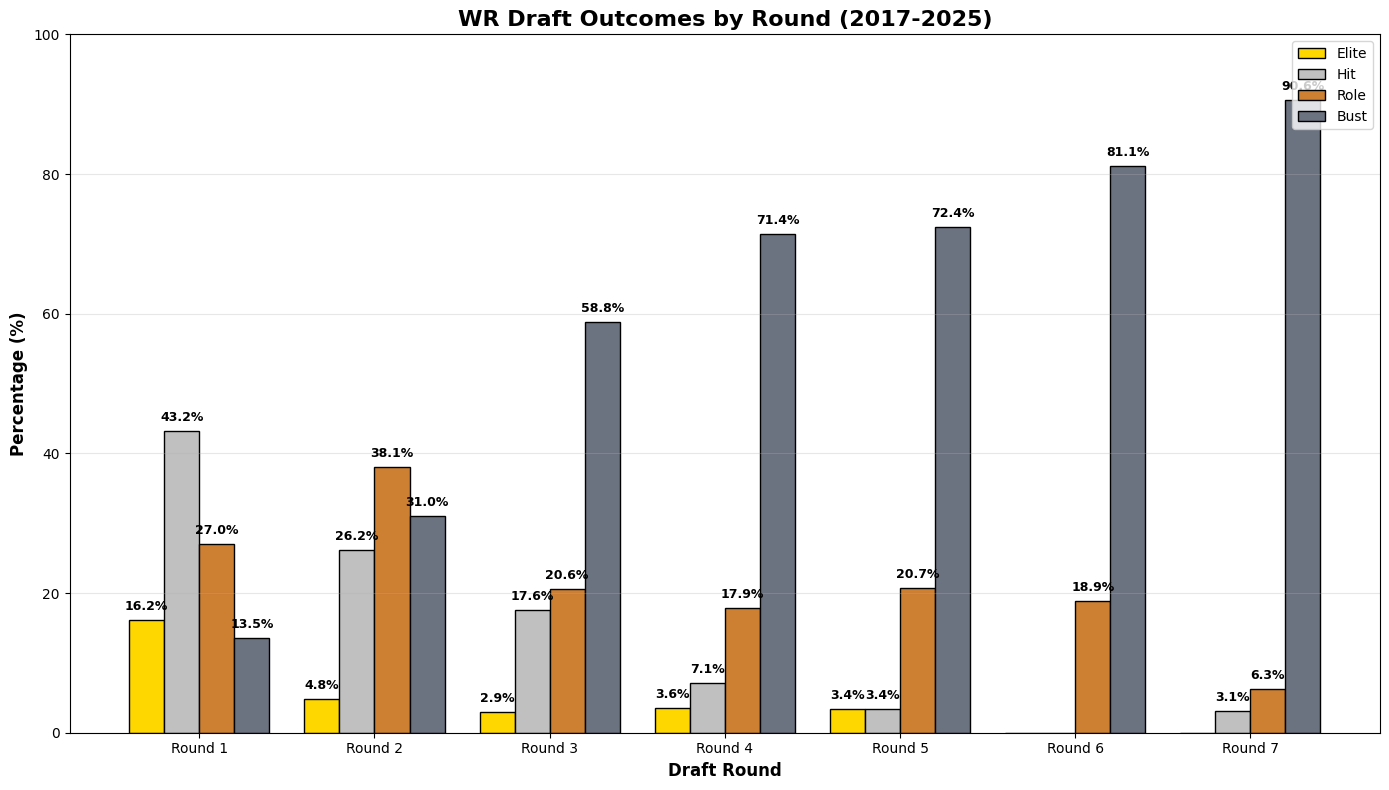


RAW PERCENTAGES BY ROUND:
Round 1.0: Elite=16.2%, Hit=43.2%, Role=27.0%, Bust=13.5%
Round 2.0: Elite=4.8%, Hit=26.2%, Role=38.1%, Bust=31.0%
Round 3.0: Elite=2.9%, Hit=17.6%, Role=20.6%, Bust=58.8%
Round 4.0: Elite=3.6%, Hit=7.1%, Role=17.9%, Bust=71.4%
Round 5.0: Elite=3.4%, Hit=3.4%, Role=20.7%, Bust=72.4%
Round 6.0: Elite=0.0%, Hit=0.0%, Role=18.9%, Bust=81.1%
Round 7.0: Elite=0.0%, Hit=3.1%, Role=6.3%, Bust=90.6%


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# get the data
rounds = results['Round']
elite = results['elite_rate']
hit = results['hit_rate']
role = results['role_rate']
bust = results['bust_rate']

# set up bar positions
x = np.arange(len(rounds))
width = 0.2

# create bars
bars1 = ax.bar(x - width*1.5, elite, width, label='Elite', color='#FFD700', edgecolor='black')
bars2 = ax.bar(x - width/2, hit, width, label='Hit', color='#C0C0C0', edgecolor='black')
bars3 = ax.bar(x + width/2, role, width, label='Role', color='#CD7F32', edgecolor='black')
bars4 = ax.bar(x + width*1.5, bust, width, label='Bust', color='#6B7280', edgecolor='black')

# customize the chart
ax.set_xlabel('Draft Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('WR Draft Outcomes by Round (2017-2025)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Round {r}' for r in rounds])
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label if bar has height
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('wr_draft_hit_rates.png', dpi=300, bbox_inches='tight')
plt.show()

# also show the raw numbers for reference
print("\nRAW PERCENTAGES BY ROUND:")
print("=" * 60)
for i, row in results.iterrows():
    print(f"Round {row['Round']}: Elite={row['elite_rate']}%, Hit={row['hit_rate']}%, Role={row['role_rate']}%, Bust={row['bust_rate']}%")

## Key Takeaways

| Round | Best Description | Draft Strategy Implication |
|-------|-----------------|---------------------------|
| 1 | Elite or bust? Actually no - 86.5% become starters | Safe investment, but elite talent still rare |
| 2 | High upside with manageable risk | Best value round - target WRs here |
| 3 | 58.8% bust rate, but 20.5% become solid starters | Acceptable risk for the upside |
| 4-7 | 70-90% bust rate | Lottery tickets - draft many, expect most to fail |

**Next Up:** In Notebook 02, I examine what drives draft position by looking at college production. Does the NFL draft for production or potential?

***
## LINKS <br><br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)
#### [College Production vs Draft Position](https://quinng8.github.io/nfl-draft-analytics/02_college_ypg_analysis.html)